In [56]:
from alphagenome.models import dna_client, variant_scorers
from alphagenome.data import gene_annotation, genome, transcript, track_data
from alphagenome.visualization import plot_components
import pandas as pd
import os
from pathlib import Path
from tqdm import tqdm
from dotenv import load_dotenv
from datetime import datetime
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)
load_dotenv(dotenv_path=".env")
API_KEYS = [v for _, v in sorted(
    ((k, os.environ[k].strip()) for k in os.environ
     if k.startswith("AG_API_KEY_") and k.removeprefix("AG_API_KEY_").isdigit()),
    key=lambda kv: int(kv[0].removeprefix("AG_API_KEY_")),
) if v]

In [39]:
LMNA_START = 156_082_572
LMNA_END = 156_140_081

# mane transcript 1:156,114,711-156,140,081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)

BASE_PATH = '/users/PAS2905/coraalbers/'

AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = f'{BASE_PATH}ag/hg38.fa'
HG38_GTF_PATH = f'{AG_DATA_PATH}gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = f'{AG_DATA_PATH}gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = f'{AG_DATA_PATH}gencode.v46.splice_sites_ends.feather'
CALIBRATION_PATH = f'{AG_DATA_PATH}calibration_scores.pb'

CLINVAR_PATH = f'{BASE_PATH}ag/clinvar.vcf.gz'

HEART_UB = 'UBERON:0000948'
LV_UB = 'UBERON:0002084'

gtf = pd.read_feather(
    HG38_GTF_PATH
)
output_modalities = ['atac',	
    'cage',	
    'chip_histone',	
    'chip_tf',	
    'contact_maps',	
    'dnase',	
    'procap',	
    'rna_seq',	
    'splice_junctions',	
    'splice_site_usage',	
    'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}

VARIANTS_PATH = f'{BASE_PATH}ag/variant-effects/osc/outputs/ism_ccres_top1_variant_strings.txt'

ccre_bed_path = f'{BASE_PATH}ag/variant-effects/osc/data_sync/predicted_ccre_like_regions_central_LV_128res.bed'

In [17]:
model = dna_client.create(API_KEYS[4])

print('API model initialized!')

API model initialized!


In [18]:
%%time 

def get_variants(variant_path):
    variants = []
    with open(variant_path, "r") as f:
        for line in f:
            # Remove the > and split by colon
            line = line.replace('>', ":")
            variants.append(line.strip().split(":"))

    return variants


variant_list = get_variants(VARIANTS_PATH)

# with open(VARIANTS_PATH, 'r') as file:
#     variant_input = [line.strip() for line in file]

# assume variants are in text file in format chr:pos:ref>alt
# can comment out if variants are already in format chr:pos:ref:alt
# variant_list = [var.replace(">", ":") for var in variant_input] 

# generate df variants
variant_df = pd.DataFrame(variant_list, columns = ['CHROM', "POS", 'REF', 'ALT'])
variant_df

CPU times: user 1.48 ms, sys: 170 μs, total: 1.65 ms
Wall time: 2.69 ms


,CHROM,POS,REF,ALT
0,chr1,156338017,C,G
1,chr1,156338069,G,T
2,chr1,156338093,G,C
3,chr1,156338116,G,T
4,chr1,156338121,G,T
...,...,...,...,...
1045,chr1,156105392,C,A
1046,chr1,156105483,A,T
1047,chr1,156105537,C,G
1048,chr1,156105544,G,C


In [84]:
organism = 'human'  # @param ["human", "mouse"] {type:"string"}

# @markdown Specify length of sequence around variants to predict:
sequence_length = '100KB'  # @param ["16KB", "100KB", "500KB", "1MB"] { type:"string" }
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
    f'SEQUENCE_LENGTH_{sequence_length}'
]


# @markdown Specify which scorers to use to score your variants:
score_rna_seq = True  # @param { type: "boolean"}
score_cage = True  # @param { type: "boolean" }
score_procap = True  # @param { type: "boolean" }
score_atac = True  # @param { type: "boolean" }
score_dnase = True  # @param { type: "boolean" }
score_chip_histone = True  # @param { type: "boolean" }
score_chip_tf = True  # @param { type: "boolean" }
score_polyadenylation = False  # @param { type: "boolean" }
score_splice_sites = True  # @param { type: "boolean" }
score_splice_site_usage = True  # @param { type: "boolean" }
score_splice_junctions = True  # @param { type: "boolean" }



# Parse organism specification.
organism_map = {
    'human': dna_client.Organism.HOMO_SAPIENS,
    'mouse': dna_client.Organism.MUS_MUSCULUS,
}
organism = organism_map[organism]

# Parse scorer specification.
scorer_selections = {
    'rna_seq': score_rna_seq,
    'cage': score_cage,
    'procap': score_procap,
    'atac': score_atac,
    'dnase': score_dnase,
    'chip_histone': score_chip_histone,
    'chip_tf': score_chip_tf,
    'polyadenylation': score_polyadenylation,
    'splice_sites': score_splice_sites,
    'splice_site_usage': score_splice_site_usage,
    'splice_junctions': score_splice_junctions,
}

all_scorers = variant_scorers.RECOMMENDED_VARIANT_SCORERS
print(all_scorers)
selected_scorers = all_scorers
selected_scorers = [
    all_scorers[key]
    for key in all_scorers
    # if scorer_selections.get(key.lower(), False)
]



# # Remove any scorers or output types that are not supported for the chosen organism.
# unsupported_scorers = [
#     scorer
#     for scorer in selected_scorers
#     if (
#         organism.value
#         not in variant_scorers.SUPPORTED_ORGANISMS[scorer.base_variant_scorer]
#     )
#     | (
#         (scorer.requested_output == dna_client.OutputType.PROCAP)
#         & (organism == dna_client.Organism.MUS_MUSCULUS)
#     )
# ]
# if len(unsupported_scorers) > 0:
#   print(
#       f'Excluding {unsupported_scorers} scorers as they are not supported for'
#       f' {organism}.'
#   )
#   for unsupported_scorer in unsupported_scorers:
#     selected_scorers.remove(unsupported_scorer)

print(selected_scorers)


immutabledict({'ATAC': CenterMaskScorer(requested_output=ATAC, width=501, aggregation_type=DIFF_LOG2_SUM), 'CONTACT_MAPS': ContactMapScorer(), 'DNASE': CenterMaskScorer(requested_output=DNASE, width=501, aggregation_type=DIFF_LOG2_SUM), 'CHIP_TF': CenterMaskScorer(requested_output=CHIP_TF, width=501, aggregation_type=DIFF_LOG2_SUM), 'CHIP_HISTONE': CenterMaskScorer(requested_output=CHIP_HISTONE, width=2001, aggregation_type=DIFF_LOG2_SUM), 'CAGE': CenterMaskScorer(requested_output=CAGE, width=501, aggregation_type=DIFF_LOG2_SUM), 'PROCAP': CenterMaskScorer(requested_output=PROCAP, width=501, aggregation_type=DIFF_LOG2_SUM), 'RNA_SEQ': GeneMaskLFCScorer(requested_output=RNA_SEQ), 'RNA_SEQ_ACTIVE': GeneMaskActiveScorer(requested_output=RNA_SEQ), 'SPLICE_SITES': GeneMaskSplicingScorer(requested_output=SPLICE_SITES, width=None), 'SPLICE_SITE_USAGE': GeneMaskSplicingScorer(requested_output=SPLICE_SITE_USAGE, width=None), 'SPLICE_JUNCTIONS': SpliceJunctionScorer(), 'POLYADENYLATION': Polyade

In [92]:
# terms = ['chr1', 155978200, "T","C"]

terms = variant_df.iloc[0]
print(terms)
variant_chromosome = terms.CHROM
variant_position = int(terms.POS)
variant_reference_bases = terms.REF
variant_alternate_bases = terms.ALT
print(variant_position)

# variant_chromosome = terms[0]
# variant_position = int(terms[1])
# variant_reference_bases = terms[2]
# variant_alternate_bases = terms[3]



CHROM         chr1
POS      156338017
REF              C
ALT              G
Name: 0, dtype: object
156338017


In [99]:
# @title Score variant { run: "auto" }
organism = 'human'  # @param ["human", "mouse"] {type:"string"}
organism_map = {
    'human': dna_client.Organism.HOMO_SAPIENS,
    'mouse': dna_client.Organism.MUS_MUSCULUS,
}
organism = organism_map[organism]

# @markdown Specify the variant:
# variant_chromosome = 'chr22'  # @param { type:"string" }
# variant_position = 36201698  # @param { type:"integer" }
# variant_reference_bases = 'A'  # @param { type:"string" }
# variant_alternate_bases = 'C'  # @param { type:"string" }



variant = genome.Variant(
    chromosome=variant_chromosome,
    position=variant_position,
    reference_bases=variant_reference_bases,
    alternate_bases=variant_alternate_bases,
)

# @markdown Specify length of sequence around variant to predict:
sequence_length = '500KB'  # @param ["2KB", "16KB", "100KB", "500KB", "1MB"] { type:"string" }
sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
    f'SEQUENCE_LENGTH_{sequence_length}'
]

# The input interval is derived from the variant (centered on it).
interval = LMNA_INTERVAL.resize(sequence_length)

# @markdown Additional settings:
variant_scores = model.score_variant(
    interval=interval,
    variant=variant,
    variant_scorers=selected_scorers,
)

df_scores = variant_scorers.tidy_scores(variant_scores)

download_predictions = False  # @param { type: "boolean" }
if download_predictions:
  df_scores.to_csv(f'{variant}_scores.csv', index=False)
  files.download(f'{variant}_scores.csv')

# @markdown Click `Filter` on the upper right hand side of the interactive dataframe and type a cell or tissue name like "brain" into the `Search by all fields box` to subset the variant scores to a specific tissue of interest:
columns = [
    c for c in df_scores.columns if c not in ['variant_id', 'scored_interval']
]
# df_scores[df_scores['ontology_curie' ] == LV_UB]
print("prediction finished")

prediction finished


In [100]:
df_scores

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,transcription_factor,histone_mark,gtex_tissue,raw_score,quantile_score
0,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000084 ATAC-seq,.,ATAC-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,NaN,NaN,NaN,-0.019269,-0.622109
1,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000100 ATAC-seq,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,NaN,NaN,NaN,-0.031112,-0.578814
2,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000236 ATAC-seq,.,ATAC-seq,CL:0000236,B cell,primary_cell,adult,encode,paired,False,NaN,NaN,NaN,-0.018390,-0.611615
3,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000623 ATAC-seq,.,ATAC-seq,CL:0000623,natural killer cell,primary_cell,adult,encode,paired,False,NaN,NaN,NaN,-0.024079,-0.775255
4,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",CL:0000624 ATAC-seq,.,ATAC-seq,CL:0000624,"CD4-positive, alpha-beta T cell",primary_cell,adult,encode,paired,False,NaN,NaN,NaN,-0.017904,-0.622109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42319,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, widt...",ENCSR182QNJ,-,PRO-cap,EFO:0001099,Caco-2,cell_line,NaN,encode,NaN,False,NaN,NaN,NaN,1916.732788,0.998861
42320,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, widt...",ENCSR740IPL,-,PRO-cap,EFO:0002067,K562,cell_line,NaN,encode,NaN,False,NaN,NaN,NaN,2529.028809,0.999291
42321,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, widt...",ENCSR797DEF,-,PRO-cap,EFO:0002819,Calu3,cell_line,NaN,encode,NaN,False,NaN,NaN,NaN,1534.679199,0.998696
42322,chr1:156338017:C>G,chr1:155865252-156389540:.,None,None,None,None,None,None,PROCAP,"CenterMaskScorer(requested_output=PROCAP, widt...",ENCSR801ECP,-,PRO-cap,CL:0002618,endothelial cell of umbilical vein,primary_cell,NaN,encode,NaN,False,NaN,NaN,NaN,1238.721313,0.998347


In [105]:
df_scores[df_scores['ontology_curie'] == LV_UB]['output_type'].unique()

array(['ATAC', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'RNA_SEQ',
       'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS'], dtype=object)

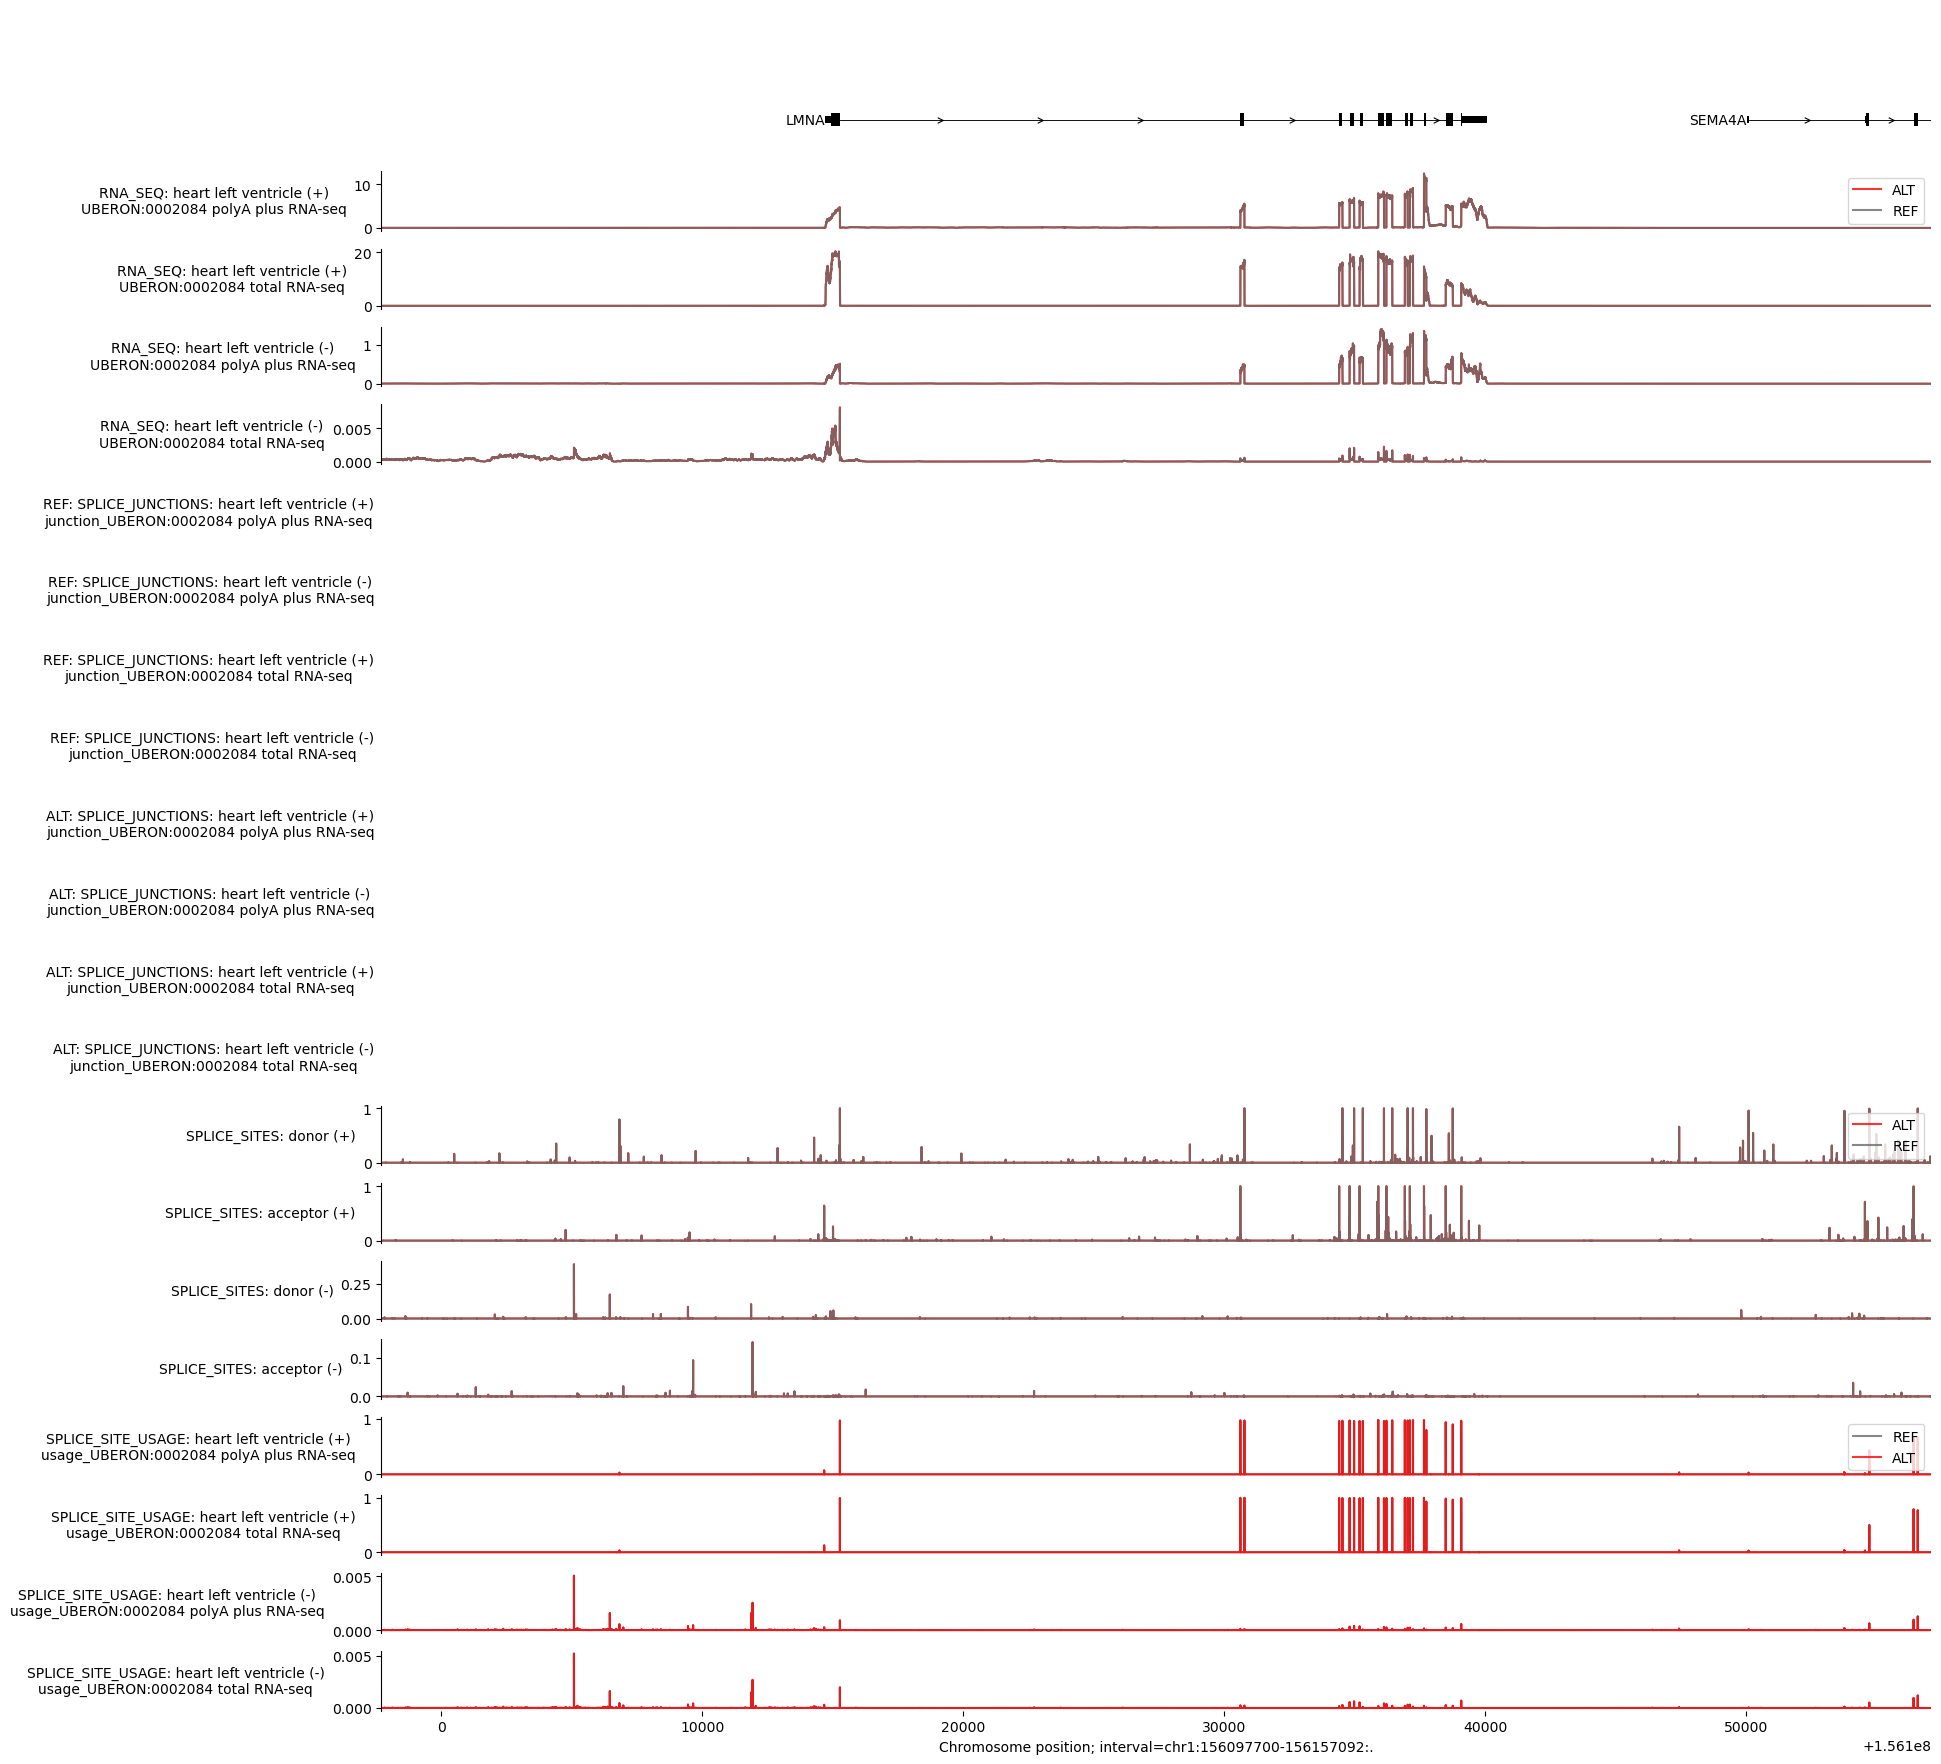

In [107]:
# Initialize an empty dictionary to serve as a variant effect prediction cache.
_prediction_cache = {}

_transcript_extractor_cache = {}


# @title Visualize variant effects { run: "auto" }
# @markdown We can also visualise the predicted effects of the variant by first predicting tracks for the REF and ALT alleles:

# @markdown Specify list of cell and tissue ontologies:
ontology_terms = [LV_UB]  # @param

# @markdown Gene and transcript annotation options:
plot_gene_annotation = True  # @param { type: "boolean" }
plot_longest_transcript_only = True  # @param { type: "boolean" }

# @markdown Output types to plot (if present in output):
plot_rna_seq = True  # @param { type: "boolean" }
plot_cage = False  # @param { type: "boolean" }
plot_atac = False  # @param { type: "boolean" }
plot_dnase = False  # @param { type: "boolean" }
plot_chip_histone = False  # @param { type: "boolean" }
plot_chip_tf = False  # @param { type: "boolean" }
plot_splice_sites = True  # @param { type: "boolean" }
plot_splice_site_usage = True  # @param { type: "boolean" }
plot_contact_maps = False  # @param { type: "boolean" }
plot_splice_junctions = True  # @param { type: "boolean" }

# @markdown Option to filter tracks to only a specific DNA strand:
filter_to_positive_strand = False  # @param { type: "boolean" }
filter_to_negative_strand = False  # @param { type: "boolean" }
if filter_to_positive_strand and filter_to_negative_strand:
  raise ValueError(
      'Cannot specify both filter_to_positive_strand and '
      'filter_to_negative_strand.'
  )

# @markdown Specify a list of Transription Factors to select from CHIP_TF outputs e.g. ['IKZF1'].
# These must be contained in the 'transcription_factor' column of the CHIP_TF metadata.
transcription_factors = None  # @param

# @markdown Other visualization options:
ref_color = 'dimgrey'  # @param { type: "string" }
alt_color = 'red'  # @param { type: "string" }
ref_alt_colors = {'REF': ref_color, 'ALT': alt_color}
plot_interval_width = 59392 # @param { type: "slider", min: 2048, max: 1048576, step: 2048}
plot_interval_shift = 0 # @param { type: "slider", min: -524288, max: 524288, step: 2048}


# Load gene annotation.
if organism in _transcript_extractor_cache:
  transcript_extractor, longest_transcript_extractor = (
      _transcript_extractor_cache[organism]
  )
else:
  match organism:
    case dna_client.Organism.HOMO_SAPIENS:
      gtf_path = HG38_GTF_PATH
    case dna_client.Organism.MUS_MUSCULUS:
      gtf_path = MM10_GTF_FEATHER
    case _:
      raise ValueError(f'Unsupported organism: {organism}')

  gtf = pd.read_feather(gtf_path)

  # Filter to protein-coding genes and highly supported transcripts.
  gtf_transcript = gene_annotation.filter_transcript_support_level(
      gene_annotation.filter_protein_coding(gtf), ['1']
  )

  # Extractor for identifying transcripts in a region.
  transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

  # Also define an extractor that fetches only the longest transcript per gene.
  gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
      gtf_transcript
  )
  longest_transcript_extractor = transcript.TranscriptExtractor(
      gtf_longest_transcript
  )
  _transcript_extractor_cache[organism] = (
      transcript_extractor,
      longest_transcript_extractor,
  )


def _predict_variant_cached(
    interval, variant, organism, requested_outputs, ontology_terms
):
  """Cache wrapper of dna_model.predict_variant."""
  # Create a unique key from the function arguments.
  cache_key = (
      str(interval),
      str(variant),
      str(organism),
      tuple(requested_outputs),
      tuple(ontology_terms),
  )

  # Check if the result is already in the cache.
  if cache_key in _prediction_cache:
    return _prediction_cache[cache_key]

  # If not, compute the prediction and store it in the cache.
  result = model.predict_variant(
      interval=interval,
      variant=variant,
      organism=organism,
      requested_outputs=requested_outputs,
      ontology_terms=ontology_terms,
  )
  _prediction_cache[cache_key] = result
  return result


output = _predict_variant_cached(
    interval=interval,
    variant=variant,
    organism=organism,
    requested_outputs=[*dna_client.OutputType],
    ontology_terms=ontology_terms,
)

# Filter to DNA strand if requested.
ref, alt = output.reference, output.alternate

if filter_to_positive_strand:
  ref = ref.filter_to_nonnegative_strand()
  alt = alt.filter_to_nonnegative_strand()
elif filter_to_negative_strand:
  ref = ref.filter_to_strand(strand='-')
  alt = alt.filter_to_strand(strand='-')

# Function to filter to TFs if requested.


def _maybe_filter_to_tfs(
    tdata: track_data.TrackData,
) -> track_data.TrackData | None:
  if not plot_chip_tf:
    return tdata

  if plot_chip_tf and (transcription_factors is not None):
    if not isinstance(transcription_factors, list):
      raise ValueError('TFs must be input as a list of strings.')
    if not isinstance(transcription_factors[0], str):
      raise ValueError('TFs must be input as a list of strings.')

  if transcription_factors is None:
    return tdata

  tf_rows = tdata.metadata.index[
      tdata.metadata['transcription_factor'].isin(transcription_factors)
  ]
  if not tf_rows.any():
    print(
        f'No tracks found for specified transcription factors and'
        f' ontology_terms.'
    )
    return None
  missing_tfs = set(transcription_factors).difference(
      set(tdata.metadata['transcription_factor'])
  )
  if missing_tfs:
    print(
        f'Could not find tracks in chip_tf outputs corresponding to the'
        f' following requested TFs'
    )
  return tdata.select_tracks_by_index(tf_rows)


# Build plot.
components = []

# Gene and transcript annotation.
if plot_gene_annotation:
  if plot_longest_transcript_only:
    transcripts = longest_transcript_extractor.extract(interval)
  else:
    transcripts = transcript_extractor.extract(interval)
  components.append(plot_components.TranscriptAnnotation(transcripts))


# Individual output type plots.
plot_map = {
    'plot_atac': (ref.atac, alt.atac, 'ATAC'),
    'plot_cage': (ref.cage, alt.cage, 'CAGE'),
    'plot_chip_histone': (ref.chip_histone, alt.chip_histone, 'CHIP_HISTONE'),
    'plot_chip_tf': (
        _maybe_filter_to_tfs(ref.chip_tf),
        _maybe_filter_to_tfs(alt.chip_tf),
        'CHIP_TF',
    ),
    'plot_contact_maps': (ref.contact_maps, alt.contact_maps, 'CONTACT_MAPS'),
    'plot_dnase': (ref.dnase, alt.dnase, 'DNASE'),
    'plot_rna_seq': (ref.rna_seq, alt.rna_seq, 'RNA_SEQ'),
    'plot_splice_junctions': (
        ref.splice_junctions,
        alt.splice_junctions,
        'SPLICE_JUNCTIONS',
    ),
    'plot_splice_sites': (ref.splice_sites, alt.splice_sites, 'SPLICE_SITES'),
    'plot_splice_site_usage': (
        ref.splice_site_usage,
        alt.splice_site_usage,
        'SPLICE_SITE_USAGE',
    ),
}

for key, (ref_data, alt_data, output_type) in plot_map.items():
  if eval(key) and ref_data is not None and ref_data.values.shape[-1] == 0:
    print(
        f'Requested plot for output {output_type} but no tracks exist in'
        ' output. This is likely because this output does not exist for your'
        ' ontologies or requested DNA strand.'
    )
  if eval(key) and ref_data and alt_data:
    match output_type:
      case 'CHIP_HISTONE':
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{histone_mark}}'
        )
      case 'CHIP_TF':
        ylabel_template = (
            f'{output_type}: {{biosample_name}}'
            ' ({strand})\n{transcription_factor}'
        )
      case 'CONTACT_MAPS':
        ylabel_template = f'{output_type}: {{biosample_name}} ({{strand}})'
      case 'SPLICE_SITES':
        ylabel_template = f'{output_type}: {{name}} ({{strand}})'
      case _:
        ylabel_template = (
            f'{output_type}: {{biosample_name}} ({{strand}})\n{{name}}'
        )

    if output_type == 'CONTACT_MAPS':
      component = plot_components.ContactMapsDiff(
          tdata=alt_data - ref_data,
          ylabel_template=ylabel_template,
      )
      components.append(component)
    elif output_type == 'SPLICE_JUNCTIONS':
      ref_plot = plot_components.Sashimi(
          ref_data,
          ylabel_template='REF: ' + ylabel_template,
          interval_contained=False,
      )
      alt_plot = plot_components.Sashimi(
          alt_data,
          ylabel_template='ALT: ' + ylabel_template,
          interval_contained=False,
      )
      components.extend([ref_plot, alt_plot])
    else:
      component = plot_components.OverlaidTracks(
          tdata={'REF': ref_data, 'ALT': alt_data},
          colors=ref_alt_colors,
          ylabel_template=ylabel_template,
      )
      components.append(component)

if plot_interval_width > interval.width:
  raise ValueError(
      f'plot_interval_width ({plot_interval_width}) must be less than '
      f'interval.width ({interval.width}).'
  )

plot = plot_components.plot(
    components=components,
    interval=LMNA_INTERVAL.shift(plot_interval_shift).resize(plot_interval_width),
    annotations=[
        plot_components.VariantAnnotation([variant]),
    ],
)

plt.savefig(f"{BASE_PATH}ag/variant-effects/osc/figs/ISM_predictions_{variant_chromosome}_{variant_position}_{variant_reference_bases}_{variant_alternate_bases}.png", dpi=300, bbox_inches="tight")


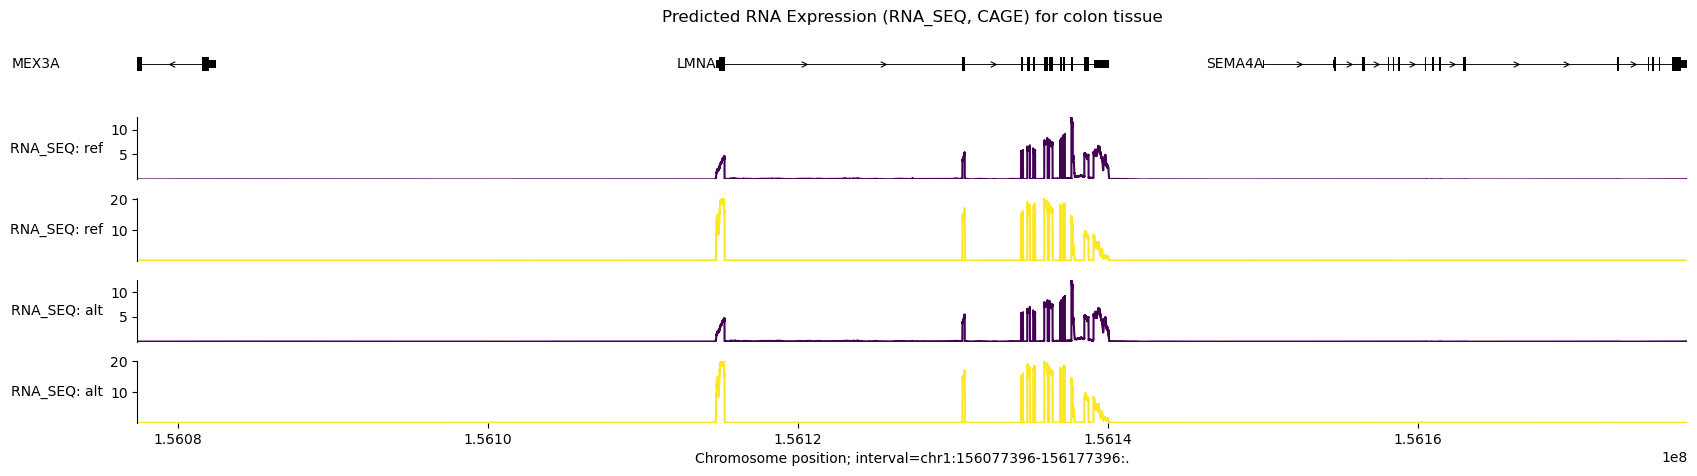

In [48]:

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
  gene_annotation.filter_protein_coding(gtf), ['1']
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
  gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
  gtf_longest_transcript
)
_transcript_extractor_cache[organism] = (
  transcript_extractor,
  longest_transcript_extractor,
)

longest_transcripts = longest_transcript_extractor.extract(interval)

# Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=ref.rna_seq.filter_to_nonpositive_strand(),
            ylabel_template='RNA_SEQ: ref',
        ),
        plot_components.Tracks(
            tdata=alt.rna_seq.filter_to_nonpositive_strand(),
            ylabel_template='RNA_SEQ: alt',
        ),
    ],
    interval=LMNA_INTERVAL.shift(plot_interval_shift).resize(plot_interval_width),
    title='Predicted RNA Expression (RNA_SEQ, CAGE) for colon tissue',
)